<a href="https://colab.research.google.com/github/mbryan56/Intro-Machine-Learning-Projects/blob/main/Homework_4_Intro_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Loading dataset from Drive: /content/drive/My Drive/Intro to ML/Datasets/Cancer.csv

=================== PROBLEM 1 METRIC RESULTS ===================
                       Accuracy  Precision  Recall  F1-Score
SVM (Linear)             0.9649     1.0000  0.9048    0.9500
SVM (Rbf)                0.9737     1.0000  0.9286    0.9630
SVM (Poly)               0.8860     1.0000  0.6905    0.8169
SVM (Sigmoid)            0.9474     0.9737  0.8810    0.9250
HW3 LogReg (Baseline)    0.9649     0.9750  0.9286    0.9512


<Figure size 1200x600 with 0 Axes>

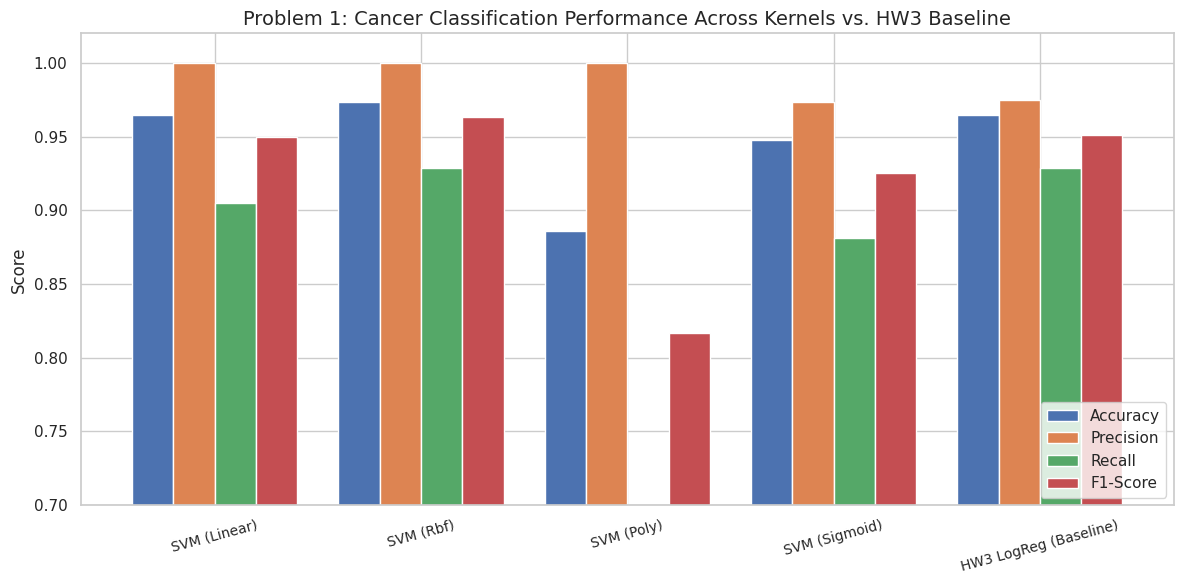

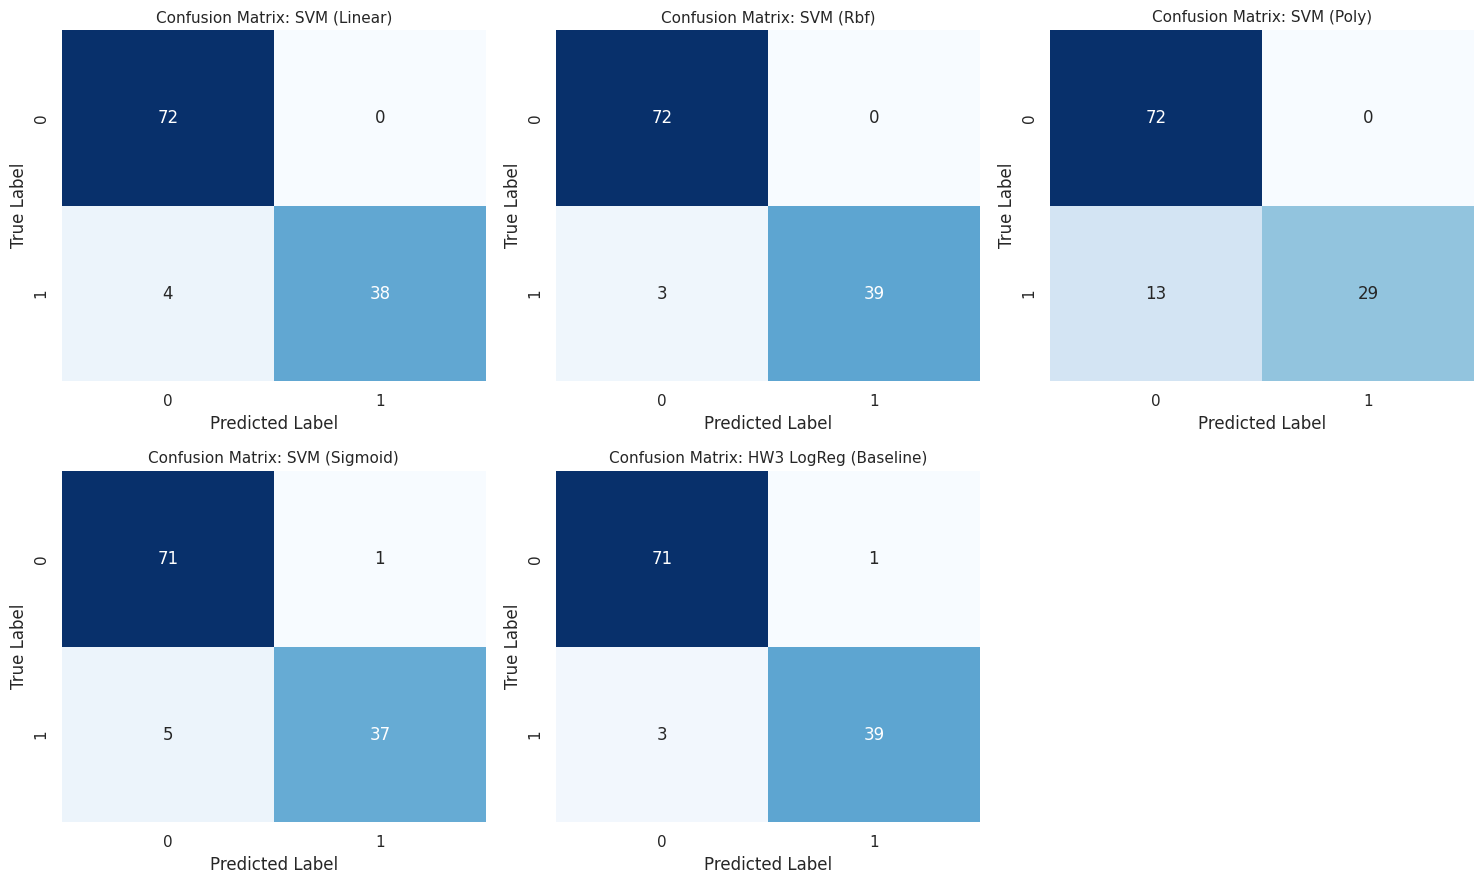

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set(style="whitegrid")

file_path = '/content/drive/My Drive/Intro to ML/Datasets/Cancer.csv'

if os.path.exists(file_path):
    print(f"Loading dataset from Drive: {file_path}")
    cancer_df = pd.read_csv(file_path)
    # Clean/Drop ID column if present
    if 'id' in cancer_df.columns:
        cancer_df = cancer_df.drop(columns=['id'])
    if 'Unnamed: 32' in cancer_df.columns:
        cancer_df = cancer_df.drop(columns=['Unnamed: 32'])

    # Map Diagnosis target (M = 1, B = 0 or vice versa depending on dataset)
    if 'diagnosis' in cancer_df.columns:
        cancer_df['diagnosis'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
        X = cancer_df.drop(columns=['diagnosis']).values
        y = cancer_df['diagnosis'].values
    else:
        X = cancer_df.iloc[:, :-1].values
        y = cancer_df.iloc[:, -1].values
else:
    print("Dataset path not found on Drive. Loading fallback built-in Breast Cancer dataset...")
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X = data.data
    y = data.target

# 3. Train-Test Split (80/20) & Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train SVM Models Across Kernels + HW3 Logistic Regression Baseline
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = {}
conf_matrices = {}

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[f'SVM ({kernel.capitalize()})'] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }
    conf_matrices[f'SVM ({kernel.capitalize()})'] = confusion_matrix(y_test, y_pred)

# HW3 Baseline (L2 Regularized Logistic Regression)
log_reg = LogisticRegression(C=1.0, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

results['HW3 LogReg (Baseline)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_lr, zero_division=0)
}
conf_matrices['HW3 LogReg (Baseline)'] = confusion_matrix(y_test, y_pred_lr)

# 5. Display Summary Metrics
df_results = pd.DataFrame(results).T
print("\n=================== PROBLEM 1 METRIC RESULTS ===================")
print(df_results.round(4))

# 6. Plot 1: Performance Metrics Comparison Bar Chart
plt.figure(figsize=(12, 6))
df_results[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title("Problem 1: Cancer Classification Performance Across Kernels vs. HW3 Baseline", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.70, 1.02)
plt.xticks(rotation=15, fontsize=10)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 7. Plot 2: Grid of Confusion Matrices for Observations
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

model_names = list(conf_matrices.keys())
for i, name in enumerate(model_names):
    sns.heatmap(conf_matrices[name], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}", fontsize=11)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

# Hide unused subplot axis
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Housing dataset from Drive: /content/drive/My Drive/Intro to ML/Datasets/Housing.csv

=================== PROBLEM 2 REGRESSION RESULTS ===================
                               MSE      RMSE ($)  R2 Score
SVR (Linear)          1.930883e+12  1.389562e+06    0.6180
SVR (Rbf)             2.037242e+12  1.427320e+06    0.5970
SVR (Poly)            2.317529e+12  1.522343e+06    0.5415
HW1 Ridge (Baseline)  1.801383e+12  1.342156e+06    0.6436


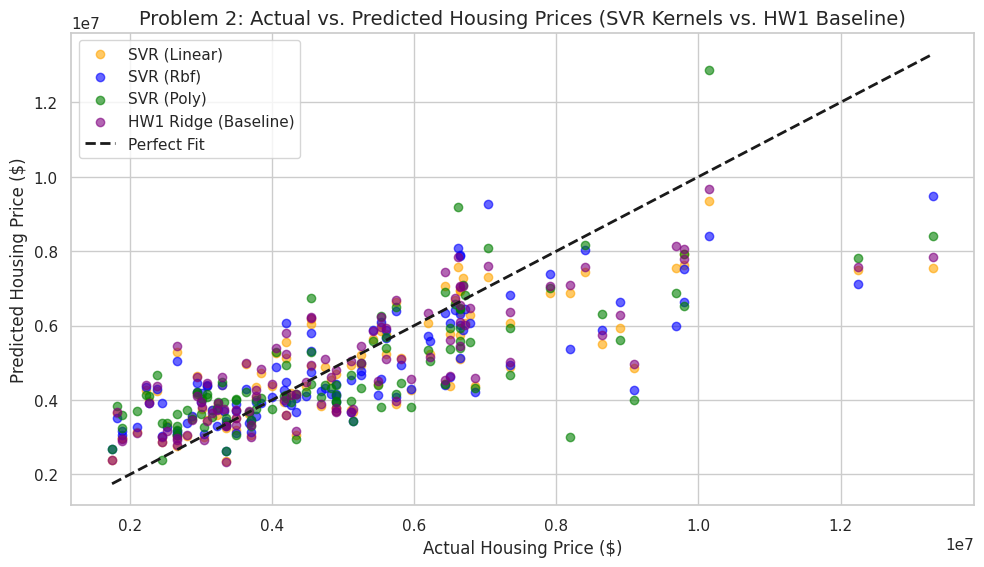

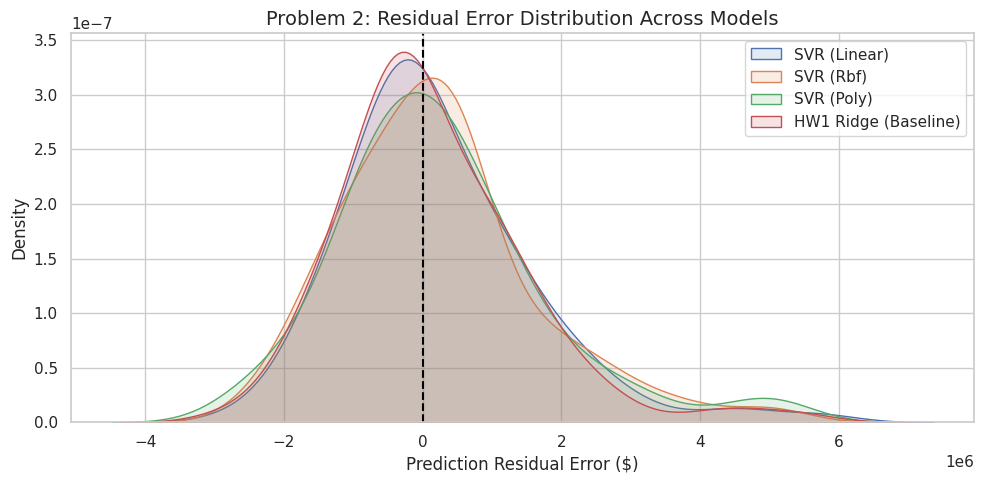

In [2]:
# ==============================================================================
# PROBLEM 2: SVR HOUSING PRICE REGRESSION WITH GOOGLE DRIVE MOUNTING
# ==============================================================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Set style for plots
sns.set(style="whitegrid")

# 2. Load Housing Dataset from Google Drive
# TODO: Adjust file path below to match your Google Drive folder structure
file_path = '/content/drive/My Drive/Intro to ML/Datasets/Housing.csv'

if os.path.exists(file_path):
    print(f"Loading Housing dataset from Drive: {file_path}")
    housing_df = pd.read_csv(file_path)
else:
    raise FileNotFoundError(f"Could not find Housing.csv at {file_path}. Please check your Drive path.")

# 3. Clean and Encode Categorical Features
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in housing_df.columns and housing_df[col].dtype == object:
        housing_df[col] = housing_df[col].map({'yes': 1, 'no': 0})

# Required input features specified in assignment
feature_cols = [
    'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
    'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
    'parking', 'prefarea'
]

X_house = housing_df[feature_cols].values
y_house = housing_df['price'].values

# 4. Train-Test Split (80/20) & Feature/Target Standardization
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.20, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_h_scaled = scaler_X.fit_transform(X_train_h)
X_test_h_scaled = scaler_X.transform(X_test_h)

y_train_h_scaled = scaler_y.fit_transform(y_train_h.reshape(-1, 1)).flatten()
y_test_h_scaled = scaler_y.transform(y_test_h.reshape(-1, 1)).flatten()

# 5. Train SVR Across Kernels + HW1 Ridge Regression Baseline
svr_kernels = ['linear', 'rbf', 'poly']
svr_results = {}
predictions = {}

for kernel in svr_kernels:
    svr = SVR(kernel=kernel, C=1.0, epsilon=0.1)
    svr.fit(X_train_h_scaled, y_train_h_scaled)

    # Predict and reverse-scale predictions back to actual house prices ($)
    y_pred_scaled = svr.predict(X_test_h_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    predictions[f'SVR ({kernel.capitalize()})'] = y_pred
    svr_results[f'SVR ({kernel.capitalize()})'] = {
        'MSE': mean_squared_error(y_test_h, y_pred),
        'RMSE ($)': np.sqrt(mean_squared_error(y_test_h, y_pred)),
        'R2 Score': r2_score(y_test_h, y_pred)
    }

# HW1 Baseline: Ridge (Regularized Linear Regression)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_h_scaled, y_train_h_scaled)
y_pred_ridge_scaled = ridge.predict(X_test_h_scaled)
y_pred_ridge = scaler_y.inverse_transform(y_pred_ridge_scaled.reshape(-1, 1)).flatten()

predictions['HW1 Ridge (Baseline)'] = y_pred_ridge
svr_results['HW1 Ridge (Baseline)'] = {
    'MSE': mean_squared_error(y_test_h, y_pred_ridge),
    'RMSE ($)': np.sqrt(mean_squared_error(y_test_h, y_pred_ridge)),
    'R2 Score': r2_score(y_test_h, y_pred_ridge)
}

# 6. Display Summary Regression Metrics
df_p2_results = pd.DataFrame(svr_results).T
print("\n=================== PROBLEM 2 REGRESSION RESULTS ===================")
print(df_p2_results.round(4))

# 7. Plot 1: Actual vs. Predicted Housing Prices Scatter Plot
plt.figure(figsize=(10, 6))

colors = {'SVR (Linear)': 'orange', 'SVR (Rbf)': 'blue', 'SVR (Poly)': 'green', 'HW1 Ridge (Baseline)': 'purple'}
for name, y_pred in predictions.items():
    plt.scatter(y_test_h, y_pred, alpha=0.6, label=name, color=colors.get(name))

# Diagonal Line representing Perfect Prediction
min_val = min(y_test_h.min(), min([p.min() for p in predictions.values()]))
max_val = max(y_test_h.max(), max([p.max() for p in predictions.values()]))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Fit')

plt.xlabel('Actual Housing Price ($)', fontsize=12)
plt.ylabel('Predicted Housing Price ($)', fontsize=12)
plt.title('Problem 2: Actual vs. Predicted Housing Prices (SVR Kernels vs. HW1 Baseline)', fontsize=14)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 8. Plot 2: Residual Errors Comparison Plot
plt.figure(figsize=(10, 5))
for name, y_pred in predictions.items():
    residuals = y_test_h - y_pred
    sns.kdeplot(residuals, label=name, fill=True, alpha=0.15)

plt.axvline(0, color='black', linestyle='--', lw=1.5)
plt.xlabel('Prediction Residual Error ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Problem 2: Residual Error Distribution Across Models', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()